In [1]:
#*********************Project Milestone 2*****************************

In [120]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from bs4 import BeautifulSoup
import requests

In [122]:
#read flat file on fantasy football into Python
df = pd.read_excel('Fantasy Football Week 1.xlsx')

df.head()

,Unnamed: 0,PLAYER NAME,PLAYER TEAM,PLAYER POSITION,OPP,ENTITY,STATUS,PROJ,PASSING C/A,PASSING YDS,PASSING TD,PASSING INT,RUSHING CAR,RUSHING YDS,RUSHING TD,RECEIVING REC,RECEIVING YDS,RECEIVING TD,RECEIVING TAR,MISC 2PC,MISC FUML,MISC TD,TOTAL
0,0,Tyreek Hill,Mia,WR,@LAC,Chargers Football HoldCo LLC,W 36-34,20.5,0/0,0,0,0,0,0,0,11,215,2,15,0,0,0,44.5
1,1,Brandon Aiyuk,SF,WR,@Pit,"Pittsburgh Steelers, LLC",W 30-7,10.6,0/0,0,0,0,0,0,0,8,129,2,8,0,0,0,32.9
2,2,Jakobi Meyers,LV,WR,@Den,"Denver Broncos Team, LLC",W 17-16,10.9,0/0,0,0,0,0,0,0,9,81,2,10,0,0,0,29.1
3,3,Tua Tagovailoa,Mia,QB,@LAC,Chargers Football HoldCo LLC,W 36-34,17.6,28/45,466,3,1,5,5,0,0,0,0,0,0,1,0,27.14
4,4,Aaron Jones,GB,RB,@Chi,"The Chicago Bears Football Club, Inc.",W 38-20,15.5,0/0,0,0,0,9,41,1,2,86,1,4,0,0,0,26.7


In [124]:
#Step 1: Find duplicate data
#Check if any of the rows were accidentally duplicated which coud affect the results of the analysis.
#It could also ccause an issue when combining all the tables together.

In [126]:
df.duplicated().any()

False

In [128]:
#Step 2: Find and sum up missing data in each column
#This step checks for any data that is missing completely and has a null value to be removed later

In [130]:
df.isnull().sum()

Unnamed: 0           0
PLAYER NAME          0
PLAYER TEAM          0
PLAYER POSITION      0
OPP                  0
ENTITY             473
STATUS             395
PROJ                 0
PASSING C/A          0
PASSING YDS          0
PASSING TD           0
PASSING INT          0
RUSHING CAR          0
RUSHING YDS          0
RUSHING TD           0
RECEIVING REC        0
RECEIVING YDS        0
RECEIVING TD         0
RECEIVING TAR        0
MISC 2PC             0
MISC FUML            0
MISC TD              0
TOTAL                0
dtype: int64

In [132]:
#Step 3: Rename headers 
#It is easier to reference headers without spaces sometimes, so I renamed important columns to be easier to reference later.
#Also clarified that TOTAL means total points and PROJ represents projected points

In [134]:
df.rename(columns={'TOTAL': 'Total_Points', 'PROJ': 'Projected_Points', 
                   'PLAYER NAME': 'Player_Name', 'PLAYER TEAM': 'Player_Team',
                   'PLAYER POSITION': 'Player_position'}, inplace=True)

In [136]:
#Step 4: Create a new column for home team
#add column named Home team to df
#use where to enter a condition (if OPP column has an @ in it, then take that value (without the @)
#otherwise if there is no @ in the OPP column then suse the data in the Player_Team column
df['Home_Team'] = np.where(
    df['OPP'].str.startswith('@'),
    df['OPP'].str[1:],  # Remove the '@'
    df['Player_Team']
)

In [138]:
df.head(10)

,Unnamed: 0,Player_Name,Player_Team,Player_position,OPP,ENTITY,STATUS,Projected_Points,PASSING C/A,PASSING YDS,PASSING TD,PASSING INT,RUSHING CAR,RUSHING YDS,RUSHING TD,RECEIVING REC,RECEIVING YDS,RECEIVING TD,RECEIVING TAR,MISC 2PC,MISC FUML,MISC TD,Total_Points,Home_Team
0,0,Tyreek Hill,Mia,WR,@LAC,Chargers Football HoldCo LLC,W 36-34,20.5,0/0,0,0,0,0,0,0,11,215,2,15,0,0,0,44.5,LAC
1,1,Brandon Aiyuk,SF,WR,@Pit,"Pittsburgh Steelers, LLC",W 30-7,10.6,0/0,0,0,0,0,0,0,8,129,2,8,0,0,0,32.9,Pit
2,2,Jakobi Meyers,LV,WR,@Den,"Denver Broncos Team, LLC",W 17-16,10.9,0/0,0,0,0,0,0,0,9,81,2,10,0,0,0,29.1,Den
3,3,Tua Tagovailoa,Mia,QB,@LAC,Chargers Football HoldCo LLC,W 36-34,17.6,28/45,466,3,1,5,5,0,0,0,0,0,0,1,0,27.14,LAC
4,4,Aaron Jones,GB,RB,@Chi,"The Chicago Bears Football Club, Inc.",W 38-20,15.5,0/0,0,0,0,9,41,1,2,86,1,4,0,0,0,26.7,Chi
5,5,Austin Ekeler,LAC,RB,Mia,Chargers Football HoldCo LLC,L 34-36,17.9,0/0,0,0,0,16,117,1,4,47,0,5,0,0,0,26.4,LAC
6,6,Stefon Diggs,Buf,WR,@NYJ,New York Jets LLC,L 16-22,16.0,0/0,0,0,0,0,0,0,10,102,1,13,0,0,0,26.2,NYJ
7,7,Christian McCaffrey,SF,RB,@Pit,"Pittsburgh Steelers, LLC",W 30-7,17.3,0/0,0,0,0,22,152,1,3,17,0,5,0,0,0,25.9,Pit
8,8,Tyler Allgeier,Atl,RB,Car,"Atlanta Falcons Football Club, LLC",W 24-10,8.8,0/0,0,0,0,15,75,2,3,19,0,3,0,0,0,24.4,Atl
9,9,Kendrick Bourne,NE,WR,Phi,"New England Patriots, LLC",L 20-25,10.0,0/0,0,0,0,0,0,0,6,64,2,11,0,0,0,24.4,NE


In [140]:
#Step 5: Remove null data
# Use dropna() to remove rows that contain null data that could mess up the final analysis. 
# The status column shows the final score of the game which is important for the final analysis if weather affects football games.

In [142]:
df = df.dropna()

In [144]:
#check if values were dropped
df.isnull().sum()

Unnamed: 0          0
Player_Name         0
Player_Team         0
Player_position     0
OPP                 0
ENTITY              0
STATUS              0
Projected_Points    0
PASSING C/A         0
PASSING YDS         0
PASSING TD          0
PASSING INT         0
RUSHING CAR         0
RUSHING YDS         0
RUSHING TD          0
RECEIVING REC       0
RECEIVING YDS       0
RECEIVING TD        0
RECEIVING TAR       0
MISC 2PC            0
MISC FUML           0
MISC TD             0
Total_Points        0
Home_Team           0
dtype: int64

In [146]:
# Step 6: Remove rows that have -- in OPP column
# Some of the rows have -- where data is missing rather than blank spots that are not considered na values so dropna() does not work
# These rows also contain missing data and should be removed.

In [148]:
df = df[df['OPP'] != '--']

In [502]:
#Step 7: change points to numeric rather than string so that an analysis can be done later one
df['Total_Points'] = pd.to_numeric(df['Total_Points'], errors='coerce')

In [508]:
#Step 8: Reset the index after removing rows
# After removing excess rows, the index will skip numbers which can get confusing on the number of total rows.

In [510]:
df.reset_index(drop=True, inplace=True)

In [512]:
#Print out the full dataframe:
#use pandas to edit the display of the data frame to ensure that all columns and rows are fully shown in a table
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

In [514]:
df

,Unnamed: 0,Player_Name,Player_Team,Player_position,OPP,ENTITY,STATUS,Projected_Points,PASSING C/A,PASSING YDS,PASSING TD,PASSING INT,RUSHING CAR,RUSHING YDS,RUSHING TD,RECEIVING REC,RECEIVING YDS,RECEIVING TD,RECEIVING TAR,MISC 2PC,MISC FUML,MISC TD,Total_Points,Home_Team
0,0,Tyreek Hill,Mia,WR,@LAC,Chargers Football HoldCo LLC,W 36-34,20.5,0/0,0,0,0,0,0,0,11,215,2,15,0,0,0,44.50,LAC
1,1,Brandon Aiyuk,SF,WR,@Pit,"Pittsburgh Steelers, LLC",W 30-7,10.6,0/0,0,0,0,0,0,0,8,129,2,8,0,0,0,32.90,Pit
2,2,Jakobi Meyers,LV,WR,@Den,"Denver Broncos Team, LLC",W 17-16,10.9,0/0,0,0,0,0,0,0,9,81,2,10,0,0,0,29.10,Den
3,3,Tua Tagovailoa,Mia,QB,@LAC,Chargers Football HoldCo LLC,W 36-34,17.6,28/45,466,3,1,5,5,0,0,0,0,0,0,1,0,27.14,LAC
4,4,Aaron Jones,GB,RB,@Chi,"The Chicago Bears Football Club, Inc.",W 38-20,15.5,0/0,0,0,0,9,41,1,2,86,1,4,0,0,0,26.70,Chi
5,5,Austin Ekeler,LAC,RB,Mia,Chargers Football HoldCo LLC,L 34-36,17.9,0/0,0,0,0,16,117,1,4,47,0,5,0,0,0,26.40,LAC
6,6,Stefon Diggs,Buf,WR,@NYJ,New York Jets LLC,L 16-22,16.0,0/0,0,0,0,0,0,0,10,102,1,13,0,0,0,26.20,NYJ
7,7,Christian McCaffrey,SF,RB,@Pit,"Pittsburgh Steelers, LLC",W 30-7,17.3,0/0,0,0,0,22,152,1,3,17,0,5,0,0,0,25.90,Pit
8,8,Tyler Allgeier,Atl,RB,Car,"Atlanta Falcons Football Club, LLC",W 24-10,8.8,0/0,0,0,0,15,75,2,3,19,0,3,0,0,0,24.40,Atl
9,9,Kendrick Bourne,NE,WR,Phi,"New England Patriots, LLC",L 20-25,10.0,0/0,0,0,0,0,0,0,6,64,2,11,0,0,0,24.40,NE


In [43]:
#************Project Milestone 3 below************

In [45]:
# url of the website that contains the table to extract
url = "https://www.nfl.com/legal/privacy/nfl-entities-list/"

# use a get request to get the html code
response = requests.get(url)
html_code = response.text

# use BeautifulSoup to parse the html code
soup = BeautifulSoup(html_code, "html.parser")

In [296]:
# Find all tables on the page
tables = soup.find_all("table")

In [298]:
#the second table on the page contains the data we are looking to extract
mytable = tables[1]

In [300]:
#find the <th> tags which show the headers in the second table
headers = [th.text.strip() for th in mytable.find_all("th")]

rows = []
#find all of the rows minus the header row
for tr in mytable.find_all("tr")[1:]: 
    #get the data from each of the td tags in each row
    tr_rows = [td.text.strip() for td in tr.find_all("td")]
    #append each row of data to the list of rows 
    if tr_rows:
        rows.append(tr_rows)

#put together the header and each row of data into a data frame with the html table on it
df2 = pd.DataFrame(rows, columns=headers)
df2.head()

,LEGAL ENTITY NAME,Registered Address/Principal Place of Business
0,"Arizona Cardinals Football Club, LLC (a Delawa...","8701 S Hardy Dr Tempe, AZ, 85284-2800"
1,"Atlanta Falcons Football Club, LLC","4400 Falcon Parkway, Flowery Branch, GA 30542"
2,Baltimore Ravens Limited Partnership,"1 Winning Drive, Owings Mills, Maryland 21117"
3,"Buffalo Bills, LLC","One Bills Drive, Orchard Park, NY 14127"
4,"Panthers Football, LLC","800 South Mint Street, Charlotte, NC, 28202-1502"


In [302]:
#clean up the data from the HTML table

#Step 1: Extract the zip code from the address column and put it into a new column called zip code
# split the info in the column by space and get the last part of the address (zip code)
df2["Zip Code"] = df2["Registered Address/Principal Place of Business"].str.split().str[-1]

In [304]:
df2.head()

,LEGAL ENTITY NAME,Registered Address/Principal Place of Business,Zip Code
0,"Arizona Cardinals Football Club, LLC (a Delawa...","8701 S Hardy Dr Tempe, AZ, 85284-2800",85284-2800
1,"Atlanta Falcons Football Club, LLC","4400 Falcon Parkway, Flowery Branch, GA 30542",30542
2,Baltimore Ravens Limited Partnership,"1 Winning Drive, Owings Mills, Maryland 21117",21117
3,"Buffalo Bills, LLC","One Bills Drive, Orchard Park, NY 14127",14127
4,"Panthers Football, LLC","800 South Mint Street, Charlotte, NC, 28202-1502",28202-1502


In [306]:
#Step 2: Remove extra digits from the zip code column so we only have 5 numbers and not the state code
#extract the first 5 numbers of the zip code column to replace current values in zip code
df2["Zip Code"] = df2["Zip Code"].str.extract(r'(\d{5})')
df2["Zip Code"].head()

0    85284
1    30542
2    21117
3    14127
4    28202
Name: Zip Code, dtype: object

In [308]:
#Step 3:  Rename headers to be simpler and easier to understand
df2.columns = ["Team_Entity_Name", "Address", "Zip_Code"]

In [310]:
df2.head()

,Team_Entity_Name,Address,Zip_Code
0,"Arizona Cardinals Football Club, LLC (a Delawa...","8701 S Hardy Dr Tempe, AZ, 85284-2800",85284
1,"Atlanta Falcons Football Club, LLC","4400 Falcon Parkway, Flowery Branch, GA 30542",30542
2,Baltimore Ravens Limited Partnership,"1 Winning Drive, Owings Mills, Maryland 21117",21117
3,"Buffalo Bills, LLC","One Bills Drive, Orchard Park, NY 14127",14127
4,"Panthers Football, LLC","800 South Mint Street, Charlotte, NC, 28202-1502",28202


In [312]:
#Step 4:  Check if there are any missing values now after the transformations have been completed
df2.isnull().sum()

Team_Entity_Name    0
Address             0
Zip_Code            1
dtype: int64

In [314]:
#find which rows where the zip code is missing from the data
missing_zip = df2[df2["Zip_Code"].isnull()]
print(missing_zip)

   Team_Entity_Name                                            Address  \
17   Union Jax, LLC  Fulham Football Club Training Ground Motspur P...   

   Zip_Code  
17      NaN  


In [316]:
#Step 5:  fill in the missing values
#each missing value has the same zip code 92626, except for one place which is in england
#england location does not matter since no teams played in england during the week chosen for this analysis
#fill in the zip code number that was missing into the null value locations
df2["Zip_Code"] = df2["Zip_Code"].fillna(92626)

In [318]:
#check to make sure that the values are filled in now
df2.head(22)

,Team_Entity_Name,Address,Zip_Code
0,"Arizona Cardinals Football Club, LLC (a Delawa...","8701 S Hardy Dr Tempe, AZ, 85284-2800",85284
1,"Atlanta Falcons Football Club, LLC","4400 Falcon Parkway, Flowery Branch, GA 30542",30542
2,Baltimore Ravens Limited Partnership,"1 Winning Drive, Owings Mills, Maryland 21117",21117
3,"Buffalo Bills, LLC","One Bills Drive, Orchard Park, NY 14127",14127
4,"Panthers Football, LLC","800 South Mint Street, Charlotte, NC, 28202-1502",28202
5,"The Chicago Bears Football Club, Inc.","1920 Football Dr Lake Forest, IL, 60045-4829",60045
6,"Dallas Cowboys Football Club, Ltd.","1 Cowboys Way Frisco, TX, 75034",75034
7,"Pro Silver Star, Ltd","1 Cowboys Way Frisco, TX, 75034",75034
8,"Blue Star Operations Services, LLC","1 Cowboys Way Frisco, TX, 75034",75034
9,"Cincinnati Bengals, Inc.","1 Paycor Stadium Cincinnati, Ohio 45202",45202


In [320]:
#check to make sure all na were filled in
df2.isnull().sum()

Team_Entity_Name    0
Address             0
Zip_Code            0
dtype: int64

In [322]:
#Step 6: Remove the England stadium from the data since it is not necessary for my analysis and to avoid any confusion.
df2 = df2.drop(17)

In [324]:
df2

,Team_Entity_Name,Address,Zip_Code
0,"Arizona Cardinals Football Club, LLC (a Delawa...","8701 S Hardy Dr Tempe, AZ, 85284-2800",85284
1,"Atlanta Falcons Football Club, LLC","4400 Falcon Parkway, Flowery Branch, GA 30542",30542
2,Baltimore Ravens Limited Partnership,"1 Winning Drive, Owings Mills, Maryland 21117",21117
3,"Buffalo Bills, LLC","One Bills Drive, Orchard Park, NY 14127",14127
4,"Panthers Football, LLC","800 South Mint Street, Charlotte, NC, 28202-1502",28202
5,"The Chicago Bears Football Club, Inc.","1920 Football Dr Lake Forest, IL, 60045-4829",60045
6,"Dallas Cowboys Football Club, Ltd.","1 Cowboys Way Frisco, TX, 75034",75034
7,"Pro Silver Star, Ltd","1 Cowboys Way Frisco, TX, 75034",75034
8,"Blue Star Operations Services, LLC","1 Cowboys Way Frisco, TX, 75034",75034
9,"Cincinnati Bengals, Inc.","1 Paycor Stadium Cincinnati, Ohio 45202",45202


In [77]:
#**************** PROJECT MILESTONE 4*********************

In [372]:
#get list of zip codes
zip_list = df2['Zip_Code'].tolist()

zip_list

['85284',
 '30542',
 '21117',
 '14127',
 '28202',
 '60045',
 '75034',
 '75034',
 '75034',
 '45202',
 '44017',
 '80112',
 '48101',
 '54304',
 '77054',
 '46254',
 '32202',
 '64129',
 '89052',
 '92626',
 '92626',
 '92626',
 '92626',
 '91301',
 '33056',
 '55121',
 '02035',
 '07073',
 '70003',
 '70003',
 '10020',
 '07932',
 '15203',
 '19145',
 '95054',
 '37228',
 '98056',
 '33607',
 '20147']

In [374]:
#remove duplicates from the list so the API isn't called unnecessarily
unique_zip = list(dict.fromkeys(zip_list))
print(unique_zip)

['85284', '30542', '21117', '14127', '28202', '60045', '75034', '45202', '44017', '80112', '48101', '54304', '77054', '46254', '32202', '64129', '89052', '92626', '91301', '33056', '55121', '02035', '07073', '70003', '10020', '07932', '15203', '19145', '95054', '37228', '98056', '33607', '20147']


In [376]:
api_key = "JPYS2YRNEY6AVN4SH9M9K4AM6"

In [378]:
#date that I want to collect weather information for
target_date = '2023-09-10'

#initialize list
weather_data = []

#loop through unique zip code list to call the api
for zip_code in unique_zip:
    #look only at september 10 2023 at different zip codes
    url = (f'https://weather.visualcrossing.com/VisualCrossingWebServices/rest/services/timeline/'
        f'{zip_code}/{target_date}/{target_date}?key={api_key}&unitGroup=us&include=days')
    
    response = requests.get(url)
    #check to make sure that it successfully connected
    if response.status_code == 200:
        #get data into a json format
        data = response.json()
        #parse the data to get the information specifically from the days key
        #put information into a dictionary
        daily_info = data.get('days')[0]

        #add zip code to dictionary
        daily_info['zipcode'] = zip_code

        #append each separate zip code info into list
        weather_data.append(daily_info)
    else:
        #if it fails to connect, tell me what zip code stopped the program and reason (status code)
        print(f"Error with {zip_code}: Status {response.status_code}")

#make weather data dictionary into a dataframe
weather_df = pd.DataFrame(weather_data)

print(weather_df)

      datetime  datetimeEpoch  tempmax  tempmin  temp  feelslikemax  \
0   2023-09-10     1694329200    110.4     90.0  99.2         110.4   
1   2023-09-10     1694318400     82.6     64.8  72.1          85.2   
2   2023-09-10     1694318400     80.4     69.0  74.0          83.5   
3   2023-09-10     1694318400     75.6     62.7  67.9          75.6   
4   2023-09-10     1694318400     83.6     69.0  74.3          85.8   
5   2023-09-10     1694322000     79.2     52.8  65.4          79.2   
6   2023-09-10     1694322000     91.4     69.6  80.2          89.4   
7   2023-09-10     1694318400     81.2     59.0  69.4          81.6   
8   2023-09-10     1694318400     69.2     61.4  65.9          69.2   
9   2023-09-10     1694325600     66.7     55.1  59.9          66.7   
10  2023-09-10     1694318400     71.4     56.3  64.1          71.4   
11  2023-09-10     1694322000     64.9     55.2  60.1          64.9   
12  2023-09-10     1694322000     93.5     77.2  85.5          90.7   
13  20

In [379]:
#Step 1: Drop the columns that we are not interested in
print(weather_df.columns)

Index(['datetime', 'datetimeEpoch', 'tempmax', 'tempmin', 'temp',
       'feelslikemax', 'feelslikemin', 'feelslike', 'dew', 'humidity',
       'precip', 'precipprob', 'precipcover', 'preciptype', 'snow',
       'snowdepth', 'windgust', 'windspeed', 'winddir', 'pressure',
       'cloudcover', 'visibility', 'solarradiation', 'solarenergy', 'uvindex',
       'sunrise', 'sunriseEpoch', 'sunset', 'sunsetEpoch', 'moonphase',
       'conditions', 'description', 'icon', 'stations', 'source', 'zipcode'],
      dtype='object')


In [380]:
#drop the columns from weather_df to make the df easier to read
weather_df = weather_df.drop(columns=['feelslikemax', 'feelslikemin', 'precipcover', 'icon', 'moonphase', 'sunsetEpoch', 'winddir', 'preciptype', 
                                      'stations', 'uvindex', 'solarenergy', 'precipprob', 'sunset', 'sunriseEpoch', 'sunrise', 'source', 
                                      'tempmax', 'tempmin', 'datetimeEpoch', 'dew', 'solarradiation', 'cloudcover', 'snowdepth', 'description'])

In [381]:
weather_df.head()

,datetime,temp,feelslike,humidity,precip,snow,windgust,windspeed,pressure,visibility,conditions,zipcode
0,2023-09-10,99.2,96.2,18.7,0.000,0.0,41.8,19.1,1007.1,9.9,Partially cloudy,85284
1,2023-09-10,72.1,72.7,81.5,0.614,0.0,16.6,7.8,1017.1,9.0,"Rain, Partially cloudy",30542
2,2023-09-10,74.0,74.3,86.2,0.110,0.0,17.2,5.5,1018.3,9.4,"Rain, Partially cloudy",21117
3,2023-09-10,67.9,67.9,80.3,0.000,0.0,12.5,8.3,1019.1,9.9,Partially cloudy,14127
4,2023-09-10,74.3,74.7,80.3,0.023,0.0,25.7,9.4,1017.9,9.1,"Rain, Partially cloudy",28202


In [382]:
#Step 2:  Check for any duplicate rows in the data which could cause a problem connecting this table to the other tables

In [383]:
#make sure that the zip code column is still unique after changes.
weather_df['zipcode'].duplicated().sum()

0

In [384]:
#Step 3:  Rename headers so that they are easier to read.
weather_df.columns = ['Date', 'Temperature', 'Feels_like_temp', 'Humidity', 'Precipitation', 'Snow', 'Wind_gust', 'Wind_speed', 'Pressure', 'Visibility', 'Weather_conditions', 'Zip_code']


In [392]:
weather_df.head()

,Date,Temperature,Feels_like_temp,Humidity,Precipitation,Snow,Wind_gust,Wind_speed,Pressure,Visibility,Weather_conditions,Zip_code
0,2023-09-10,99.2,96.2,18.7,0.000,0.0,41.8,19.1,1007.1,9.9,Partially cloudy,85284
1,2023-09-10,72.1,72.7,81.5,0.614,0.0,16.6,7.8,1017.1,9.0,"Rain, Partially cloudy",30542
2,2023-09-10,74.0,74.3,86.2,0.110,0.0,17.2,5.5,1018.3,9.4,"Rain, Partially cloudy",21117
3,2023-09-10,67.9,67.9,80.3,0.000,0.0,12.5,8.3,1019.1,9.9,Partially cloudy,14127
4,2023-09-10,74.3,74.7,80.3,0.023,0.0,25.7,9.4,1017.9,9.1,"Rain, Partially cloudy",28202


Text(0, 0.5, 'Count')

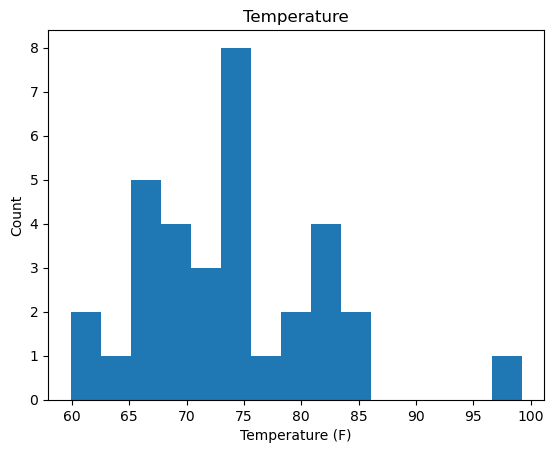

In [394]:
#Step 4: Look for outliers by creating histograms to see if there are any extreme situations
import matplotlib.pyplot as plt

plt.hist(weather_df['Temperature'], bins=15)
plt.title('Temperature')
plt.xlabel('Temperature (F)')
plt.ylabel('Count')

Text(0, 0.5, 'Count')

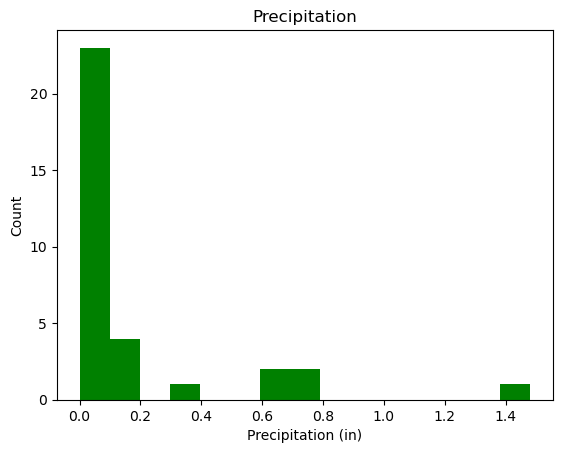

In [396]:
#check precipitation amounts
plt.hist(weather_df['Precipitation'], bins=15, color = 'green')
plt.title('Precipitation')
plt.xlabel('Precipitation (in)')
plt.ylabel('Count')

Text(0, 0.5, 'Count')

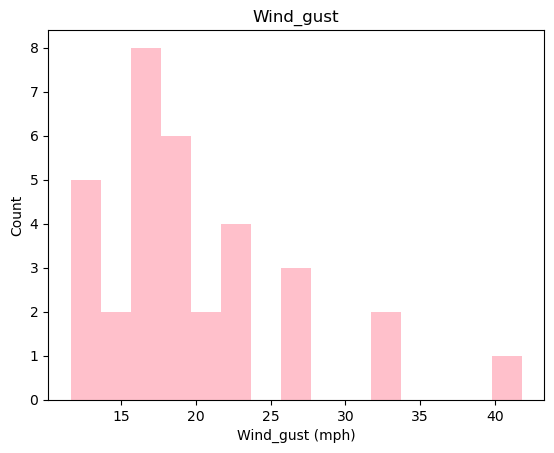

In [398]:
#check wind gusts
plt.hist(weather_df['Wind_gust'], bins=15, color = 'pink')
plt.title('Wind_gust')
plt.xlabel('Wind_gust (mph)')
plt.ylabel('Count')

In [400]:
#based on the hisotgrams, it does seem like some zipe codes had extreme weather conditions including a high temperature or 
#wind gusts up to 40 mph. I don't believe that these numbers are extreme enough though to be removed/thought of as bad data.

In [402]:
#Step 5: Check if there is any data that is not 0 for snow and if so then drop the column (unnecessary)

In [404]:
weather_df['Snow'].value_counts()

Snow
0.0    33
Name: count, dtype: int64

In [406]:
#Results show no snow for any of the locations so the column will be dropped to keep the df simple.
weather_df = weather_df.drop(columns=['Snow'])

In [408]:
weather_df

,Date,Temperature,Feels_like_temp,Humidity,Precipitation,Wind_gust,Wind_speed,Pressure,Visibility,Weather_conditions,Zip_code
0,2023-09-10,99.2,96.2,18.7,0.000,41.8,19.1,1007.1,9.9,Partially cloudy,85284
1,2023-09-10,72.1,72.7,81.5,0.614,16.6,7.8,1017.1,9.0,"Rain, Partially cloudy",30542
2,2023-09-10,74.0,74.3,86.2,0.110,17.2,5.5,1018.3,9.4,"Rain, Partially cloudy",21117
3,2023-09-10,67.9,67.9,80.3,0.000,12.5,8.3,1019.1,9.9,Partially cloudy,14127
4,2023-09-10,74.3,74.7,80.3,0.023,25.7,9.4,1017.9,9.1,"Rain, Partially cloudy",28202
5,2023-09-10,65.4,65.4,69.3,0.001,18.8,8.7,1020.3,9.9,"Rain, Partially cloudy",60045
6,2023-09-10,80.2,79.7,50.2,0.000,19.7,10.8,1017.4,9.9,Clear,75034
7,2023-09-10,69.4,69.5,71.6,0.000,15.7,9.4,1019.2,9.2,Partially cloudy,45202
8,2023-09-10,65.9,65.9,83.7,0.026,18.6,8.9,1020.8,9.6,"Rain, Overcast",44017
9,2023-09-10,59.9,59.9,72.5,0.151,21.9,13.7,1021.0,9.0,"Rain, Partially cloudy",80112


In [411]:
#**************Project Milestone 5*********************

In [413]:
import sqlite3

In [415]:
conn = sqlite3.connect('football_stats.db')

In [417]:
c = conn.cursor()

In [554]:
#use to_sql to convert each data frame to its own table in the database
df.to_sql('Fantasy', conn, if_exists='replace', index=False)
df2.to_sql('Locations', conn, if_exists='replace', index=False)
weather_df.to_sql('Weather', conn, if_exists='replace', index=False)

33

In [556]:
#execute a join query to test if it works
c.execute('select * from Fantasy f left join Locations on f.ENTITY = Locations.Team_Entity_Name inner join Weather w on w.Zip_code = Locations.Zip_code')

In [558]:
#put the query into a variable
query = 'select * from Fantasy f left join Locations on f.ENTITY = Locations.Team_Entity_Name inner join Weather w on w.Zip_code = Locations.Zip_code'

In [562]:
#use read_sql_query to run the query and convert the results into a dataframe 
final_df = pd.read_sql_query(query, conn)

final_df.head()

,Unnamed: 0,Player_Name,Player_Team,Player_position,OPP,ENTITY,STATUS,Projected_Points,PASSING C/A,PASSING YDS,PASSING TD,PASSING INT,RUSHING CAR,RUSHING YDS,RUSHING TD,RECEIVING REC,RECEIVING YDS,RECEIVING TD,RECEIVING TAR,MISC 2PC,MISC FUML,MISC TD,Total_Points,Home_Team,Team_Entity_Name,Address,Zip_Code,Date,Temperature,Feels_like_temp,Humidity,Precipitation,Wind_gust,Wind_speed,Pressure,Visibility,Weather_conditions,Zip_code
0,0,Tyreek Hill,Mia,WR,@LAC,Chargers Football HoldCo LLC,W 36-34,20.5,0/0,0,0,0,0,0,0,11,215,2,15,0,0,0,44.50,LAC,Chargers Football HoldCo LLC,"3333 Susan Street, Costa Mesa, CA 92626.",92626,2023-09-10,76.4,76.7,65.6,0.001,19.7,12.4,1012.7,9.8,"Rain, Partially cloudy",92626
1,1,Brandon Aiyuk,SF,WR,@Pit,"Pittsburgh Steelers, LLC",W 30-7,10.6,0/0,0,0,0,0,0,0,8,129,2,8,0,0,0,32.90,Pit,"Pittsburgh Steelers, LLC","3200 S. Water St, Pittsburgh, PA 15203",15203,2023-09-10,69.3,69.3,82.4,0.000,12.5,6.9,1018.5,9.1,Partially cloudy,15203
2,2,Jakobi Meyers,LV,WR,@Den,"Denver Broncos Team, LLC",W 17-16,10.9,0/0,0,0,0,0,0,0,9,81,2,10,0,0,0,29.10,Den,"Denver Broncos Team, LLC","13655 Broncos Pkwy, Englewood, CO, 80112",80112,2023-09-10,59.9,59.9,72.5,0.151,21.9,13.7,1021.0,9.0,"Rain, Partially cloudy",80112
3,3,Tua Tagovailoa,Mia,QB,@LAC,Chargers Football HoldCo LLC,W 36-34,17.6,28/45,466,3,1,5,5,0,0,0,0,0,0,1,0,27.14,LAC,Chargers Football HoldCo LLC,"3333 Susan Street, Costa Mesa, CA 92626.",92626,2023-09-10,76.4,76.7,65.6,0.001,19.7,12.4,1012.7,9.8,"Rain, Partially cloudy",92626
4,4,Aaron Jones,GB,RB,@Chi,"The Chicago Bears Football Club, Inc.",W 38-20,15.5,0/0,0,0,0,9,41,1,2,86,1,4,0,0,0,26.70,Chi,"The Chicago Bears Football Club, Inc.","1920 Football Dr Lake Forest, IL, 60045-4829",60045,2023-09-10,65.4,65.4,69.3,0.001,18.8,8.7,1020.3,9.9,"Rain, Partially cloudy",60045


In [443]:
import matplotlib.pyplot as plt

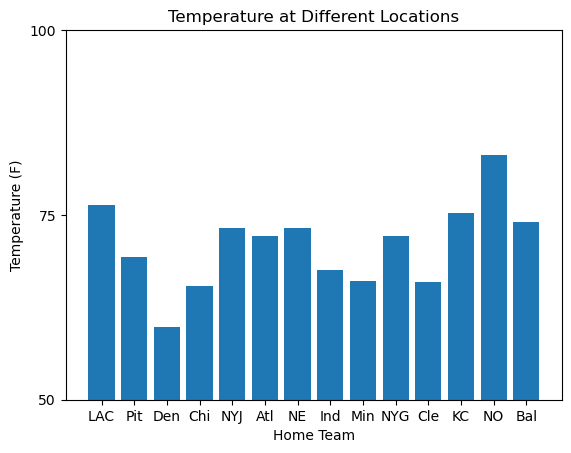

In [582]:
#see how temperature varies between the different locations where all of the games were played
plt.bar(final_df['Home_Team'], final_df['Temperature'])
plt.title('Temperature at Different Locations')
plt.xlabel('Home Team')
plt.ylabel('Temperature (F)')
plt.ylim(bottom=50)
plt.yticks([50, 75, 100])
plt.show()

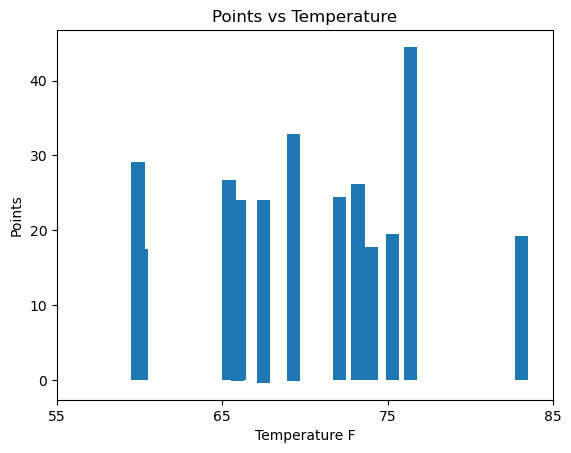

In [586]:
#see if the temperature affects points, if higher temps might lead to more points or vice versa
plt.bar(final_df['Temperature'], final_df['Total_Points'])

plt.title('Points vs Temperature')
plt.xlabel('Temperature F')
plt.ylabel('Points')
plt.xticks([55, 65, 75, 85])
plt.show()

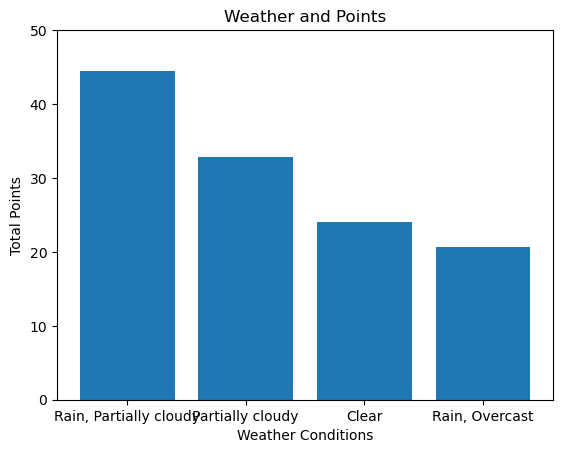

In [574]:
#need to change final df total points to numeric
final_df['Total_Points'] = pd.to_numeric(final_df['Total_Points'], errors='coerce')
#see where more points were gained based on various weather conditions
plt.bar(final_df['Weather_conditions'], final_df['Total_Points'])

plt.title('Weather and Points')
plt.xlabel('Weather Conditions')
plt.ylabel('Total Points')
plt.yticks([0, 10, 20, 30, 40, 50])
plt.ylim(bottom=0) 
plt.show()

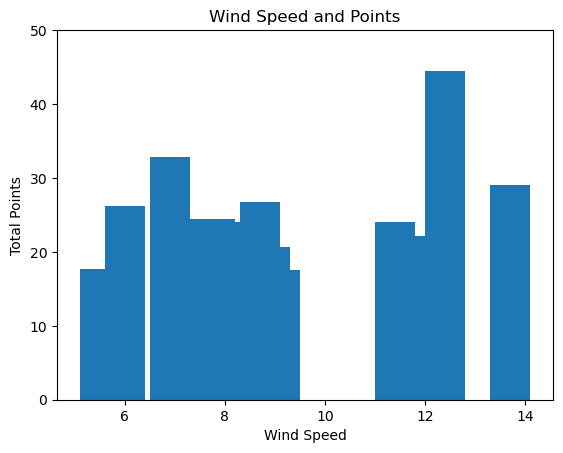

In [570]:
#see how wind speed may affect points or if it does not make a difference
plt.bar(final_df['Wind_speed'], final_df['Total_Points'])

plt.title('Wind Speed and Points')
plt.xlabel('Wind Speed')
plt.ylabel('Total Points')
plt.yticks([0, 10, 20, 30, 40, 50])
plt.ylim(bottom=0) 
plt.show()

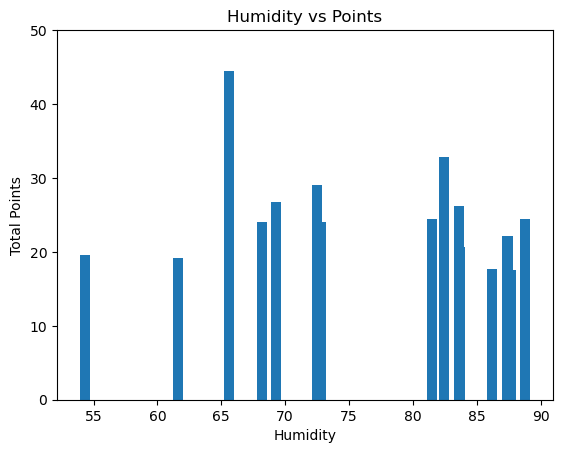

In [572]:
#see how points may vary with different humidity levels
plt.bar(final_df['Humidity'], final_df['Total_Points'])

plt.title('Humidity vs Points')
plt.xlabel('Humidity')
plt.ylabel('Total Points')
plt.yticks([0, 10, 20, 30, 40, 50])
plt.ylim(bottom=0) 
plt.show()

In [584]:
final_df

,Unnamed: 0,Player_Name,Player_Team,Player_position,OPP,ENTITY,STATUS,Projected_Points,PASSING C/A,PASSING YDS,PASSING TD,PASSING INT,RUSHING CAR,RUSHING YDS,RUSHING TD,RECEIVING REC,RECEIVING YDS,RECEIVING TD,RECEIVING TAR,MISC 2PC,MISC FUML,MISC TD,Total_Points,Home_Team,Team_Entity_Name,Address,Zip_Code,Date,Temperature,Feels_like_temp,Humidity,Precipitation,Wind_gust,Wind_speed,Pressure,Visibility,Weather_conditions,Zip_code
0,0,Tyreek Hill,Mia,WR,@LAC,Chargers Football HoldCo LLC,W 36-34,20.5,0/0,0,0,0,0,0,0,11,215,2,15,0,0,0,44.50,LAC,Chargers Football HoldCo LLC,"3333 Susan Street, Costa Mesa, CA 92626.",92626,2023-09-10,76.4,76.7,65.6,0.001,19.7,12.4,1012.7,9.8,"Rain, Partially cloudy",92626
1,1,Brandon Aiyuk,SF,WR,@Pit,"Pittsburgh Steelers, LLC",W 30-7,10.6,0/0,0,0,0,0,0,0,8,129,2,8,0,0,0,32.90,Pit,"Pittsburgh Steelers, LLC","3200 S. Water St, Pittsburgh, PA 15203",15203,2023-09-10,69.3,69.3,82.4,0.000,12.5,6.9,1018.5,9.1,Partially cloudy,15203
2,2,Jakobi Meyers,LV,WR,@Den,"Denver Broncos Team, LLC",W 17-16,10.9,0/0,0,0,0,0,0,0,9,81,2,10,0,0,0,29.10,Den,"Denver Broncos Team, LLC","13655 Broncos Pkwy, Englewood, CO, 80112",80112,2023-09-10,59.9,59.9,72.5,0.151,21.9,13.7,1021.0,9.0,"Rain, Partially cloudy",80112
3,3,Tua Tagovailoa,Mia,QB,@LAC,Chargers Football HoldCo LLC,W 36-34,17.6,28/45,466,3,1,5,5,0,0,0,0,0,0,1,0,27.14,LAC,Chargers Football HoldCo LLC,"3333 Susan Street, Costa Mesa, CA 92626.",92626,2023-09-10,76.4,76.7,65.6,0.001,19.7,12.4,1012.7,9.8,"Rain, Partially cloudy",92626
4,4,Aaron Jones,GB,RB,@Chi,"The Chicago Bears Football Club, Inc.",W 38-20,15.5,0/0,0,0,0,9,41,1,2,86,1,4,0,0,0,26.70,Chi,"The Chicago Bears Football Club, Inc.","1920 Football Dr Lake Forest, IL, 60045-4829",60045,2023-09-10,65.4,65.4,69.3,0.001,18.8,8.7,1020.3,9.9,"Rain, Partially cloudy",60045
5,5,Austin Ekeler,LAC,RB,Mia,Chargers Football HoldCo LLC,L 34-36,17.9,0/0,0,0,0,16,117,1,4,47,0,5,0,0,0,26.40,LAC,Chargers Football HoldCo LLC,"3333 Susan Street, Costa Mesa, CA 92626.",92626,2023-09-10,76.4,76.7,65.6,0.001,19.7,12.4,1012.7,9.8,"Rain, Partially cloudy",92626
6,6,Stefon Diggs,Buf,WR,@NYJ,New York Jets LLC,L 16-22,16.0,0/0,0,0,0,0,0,0,10,102,1,13,0,0,0,26.20,NYJ,New York Jets LLC,"One Jets Drive Florham Park, NJ 07932",07932,2023-09-10,73.2,73.2,83.6,0.616,15.9,6.0,1019.1,9.4,"Rain, Partially cloudy",07932
7,7,Christian McCaffrey,SF,RB,@Pit,"Pittsburgh Steelers, LLC",W 30-7,17.3,0/0,0,0,0,22,152,1,3,17,0,5,0,0,0,25.90,Pit,"Pittsburgh Steelers, LLC","3200 S. Water St, Pittsburgh, PA 15203",15203,2023-09-10,69.3,69.3,82.4,0.000,12.5,6.9,1018.5,9.1,Partially cloudy,15203
8,8,Tyler Allgeier,Atl,RB,Car,"Atlanta Falcons Football Club, LLC",W 24-10,8.8,0/0,0,0,0,15,75,2,3,19,0,3,0,0,0,24.40,Atl,"Atlanta Falcons Football Club, LLC","4400 Falcon Parkway, Flowery Branch, GA 30542",30542,2023-09-10,72.1,72.7,81.5,0.614,16.6,7.8,1017.1,9.0,"Rain, Partially cloudy",30542
9,9,Kendrick Bourne,NE,WR,Phi,"New England Patriots, LLC",L 20-25,10.0,0/0,0,0,0,0,0,0,6,64,2,11,0,0,0,24.40,NE,"New England Patriots, LLC","1 Patriot Pl Foxboro, MA, 02035-1388",02035,2023-09-10,73.2,73.3,88.8,0.329,21.7,7.5,1019.7,6.0,"Rain, Partially cloudy",02035
